# AR & FOXA1 in LNCaP (±DHT)

How the **androgen receptor (AR)** cistrome depends on the pioneer factor
**FOXA1** after androgen (DHT) stimulation in LNCaP cells.

Data are ChIP-Atlas (hg38) peaks + bigwigs — run `./download_data.sh` first.
LNCaP, 0h vs 4h DHT, for FOXA1, AR, and ATAC-seq (two ATAC replicates / condition).

> **Note** — FOXA1 4h peaks use `SRX23002841.05.bed` (matching the FOXA1 4h
> bigwig). The reference paths in the next cell point at the lackgrp cluster;
> edit them for your environment.

## 0. Setup — paths & helpers

In [1]:
import os, time
from contextlib import contextmanager

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import genomeblocks as gb
from genomeblocks import Loci, Genes, Atlas, tmm, browser
from genomeblocks.signal_draw import plot_heatmap
from genomeblocks.motifs import scan_motifs_matrix, bootstrap_enrichment


@contextmanager
def timer(label):
    """Print a step's wall-clock time."""
    t0 = time.perf_counter()
    print(f"\u25b6 {label} ...")
    try:
        yield
    finally:
        print(f"\u2713 {label} \u2014 {time.perf_counter() - t0:.1f}s")


# --- downloaded data (see download_data.sh) ---
DATA = "data"
DATA
SRX = {
    "FOXA1_0h": "SRX23002839", "FOXA1_4h": "SRX23002841",
    "AR_0h":    "SRX23002834", "AR_4h":    "SRX23002836",
    "ATAC_0h_r1": "SRX23002894", "ATAC_0h_r2": "SRX23002895",
    "ATAC_4h_r1": "SRX23002898", "ATAC_4h_r2": "SRX23002899",
}
PEAK = {k: f"{DATA}/{s}.05.bed" for k, s in SRX.items()}
BW   = {k: f"{DATA}/{s}.bw"     for k, s in SRX.items()}

# --- hg38 references (edit for your environment) ---
GENOME_FA   = "/groups/lackgrp/genome_annotations/hg38/hg38.fa"
GTF         = "/groups/lackgrp/genome_annotations/hg38/gencode.v49.annotation_protein_coding.gtf"
MOTIF_DB    = "/groups/lackgrp/databases/motifs/motif-db/H14CORE_jaspar_format_lightmotif.txt"
CHROMSIZES  = "/groups/lackgrp/genome_annotations/hg38/hg38_chr.chrom.sizes"
GIGGLE_META = "/groups/lackgrp/databases/giggle/giggle_hg38/hg38_tfs_meta.tsv"
GIGGLE_DIR  = "/groups/lackgrp/databases/giggle/giggle_hg38/ChIP-Atlas-ALL"

## 1. Load peaks

In [2]:
with timer("load peak files"):
    peaks = {k: Loci.make(v) for k, v in PEAK.items()}

for k, v in peaks.items():
    print(f"{k:12} {len(v):>8,} peaks")

▶ load peak files ...
✓ load peak files — 3.5s
FOXA1_0h        8,657 peaks
FOXA1_4h       10,870 peaks
AR_0h             910 peaks
AR_4h           3,645 peaks
ATAC_0h_r1     53,671 peaks
ATAC_0h_r2     62,741 peaks
ATAC_4h_r1     47,780 peaks
ATAC_4h_r2     51,196 peaks


## 2. Accessible chromatin — union of ATAC peaks

Concatenate the four ATAC peak sets (both conditions, both reps) and `merge()`
overlapping intervals into one accessible-region set (the result comes back in
genome order).

In [3]:
with timer("ATAC union (accessible regions)"):
    accessible = (peaks["ATAC_0h_r1"] + peaks["ATAC_0h_r2"]
                  + peaks["ATAC_4h_r1"] + peaks["ATAC_4h_r2"]).merge()

print(f"accessible regions (merged): {len(accessible):,}")

▶ ATAC union (accessible regions) ...
✓ ATAC union (accessible regions) — 0.1s
accessible regions (merged): 72,470


## 3. AR / FOXA1 binding inside vs outside accessible chromatin

AR_0h       31.2% inside accessible (284/910)
AR_4h       83.0% inside accessible (3,027/3,645)
FOXA1_0h    85.0% inside accessible (7,362/8,657)
FOXA1_4h    88.0% inside accessible (9,561/10,870)


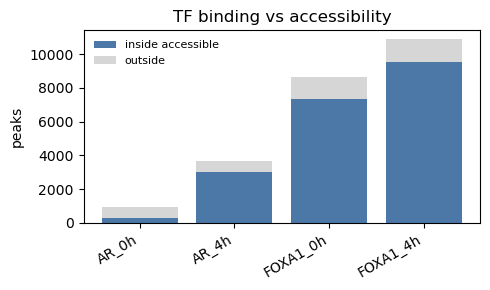

In [4]:
rows = []
for name in ["AR_0h", "AR_4h", "FOXA1_0h", "FOXA1_4h"]:
    s = peaks[name]
    inside = len(s & accessible)              # peaks overlapping accessible
    total = len(s)
    rows.append((name, inside, total - inside))
    print(f"{name:10} {100 * inside / total:5.1f}% inside accessible ({inside:,}/{total:,})")

names = [r[0] for r in rows]
ins   = np.array([r[1] for r in rows])
outs  = np.array([r[2] for r in rows])
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(names, ins,  label="inside accessible", color="#4c78a8")
ax.bar(names, outs, bottom=ins, label="outside", color="#d6d6d6")
ax.set_ylabel("peaks"); ax.legend(frameon=False, fontsize=8)
ax.set_title("TF binding vs accessibility")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()

## 4. Keep only accessible TF peaks

In [5]:
with timer("filter TF peaks to accessible"):
    F0 = peaks["FOXA1_0h"] & accessible
    F4 = peaks["FOXA1_4h"] & accessible
    A4 = peaks["AR_4h"]    & accessible

print(f"accessible  FOXA1 0h={len(F0):,}  FOXA1 4h={len(F4):,}  AR 4h={len(A4):,}")

▶ filter TF peaks to accessible ...
✓ filter TF peaks to accessible — 0.0s
accessible  FOXA1 0h=7,362  FOXA1 4h=9,561  AR 4h=3,027


## 5. Venn — FOXA1 (0h, 4h) vs AR (4h)

To venn genomic intervals we merge all peaks into a shared region *universe*,
then label each region by which input set overlaps it (`overlap_any` gives one
boolean per universe row; the row numbers are the region ids). From this:

- **AR+F** = AR 4h peaks that overlap FOXA1 (0h or 4h) — FOXA1-dependent AR
- **AR−F** = AR 4h peaks that overlap no FOXA1 peak — FOXA1-independent AR

▶ venn3 membership ...
✓ venn3 membership — 0.0s


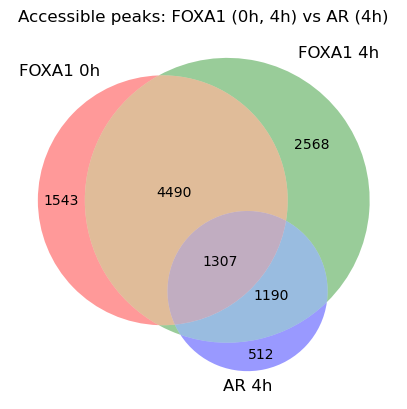

In [6]:
from matplotlib_venn import venn3

def venn_id_sets(sets):
    """Merge all peaks into a region universe; return one set of region-ids per
    input set (the ids it overlaps) so matplotlib_venn can count the regions."""
    universe = sum(sets[1:], sets[0]).merge()
    return [set(np.flatnonzero(universe.overlap_any(s)).tolist()) for s in sets]

with timer("venn3 membership"):
    ids = venn_id_sets([F0, F4, A4])

fig, ax = plt.subplots(figsize=(5, 5))
venn3(ids, set_labels=["FOXA1 0h", "FOXA1 4h", "AR 4h"], ax=ax)
ax.set_title("Accessible peaks: FOXA1 (0h, 4h) vs AR (4h)")
plt.show()

In [7]:
with timer("define AR+F / AR-F"):
    F_any = (F0 + F4).merge()            # FOXA1-bound at either timepoint
    ARpF  = A4 & F_any                   # AR 4h that IS FOXA1-bound
    ARmF  = A4 - F_any                   # AR 4h that is NOT FOXA1-bound

print(f"AR+F (FOXA1-dependent): {len(ARpF):,}   AR-F (FOXA1-independent): {len(ARmF):,}")

▶ define AR+F / AR-F ...
✓ define AR+F / AR-F — 0.0s
AR+F (FOXA1-dependent): 2,515   AR-F (FOXA1-independent): 512


## 6. Signal heatmaps across conditions

Extract signal for AR+F and AR−F over all 8 bigwigs, average the two ATAC
replicates per condition (the same averaging the browser does), and draw a
grouped heatmap: ATAC 0h, ATAC 4h, AR 0h, AR 4h, FOXA1 0h, FOXA1 4h.

▶ extract signal cube ...
[INFO] Extracting 8 bigwigs for 3027 loci into 200 bins (span=False, agg='mean', backend='pybigtools', exact=True, workers=4).


chunks: 100%|██████████| 4/4 [00:03<00:00,  1.26it/s]


✓ extract signal cube — 3.3s
▶ draw heatmap ...
✓ draw heatmap — 0.2s


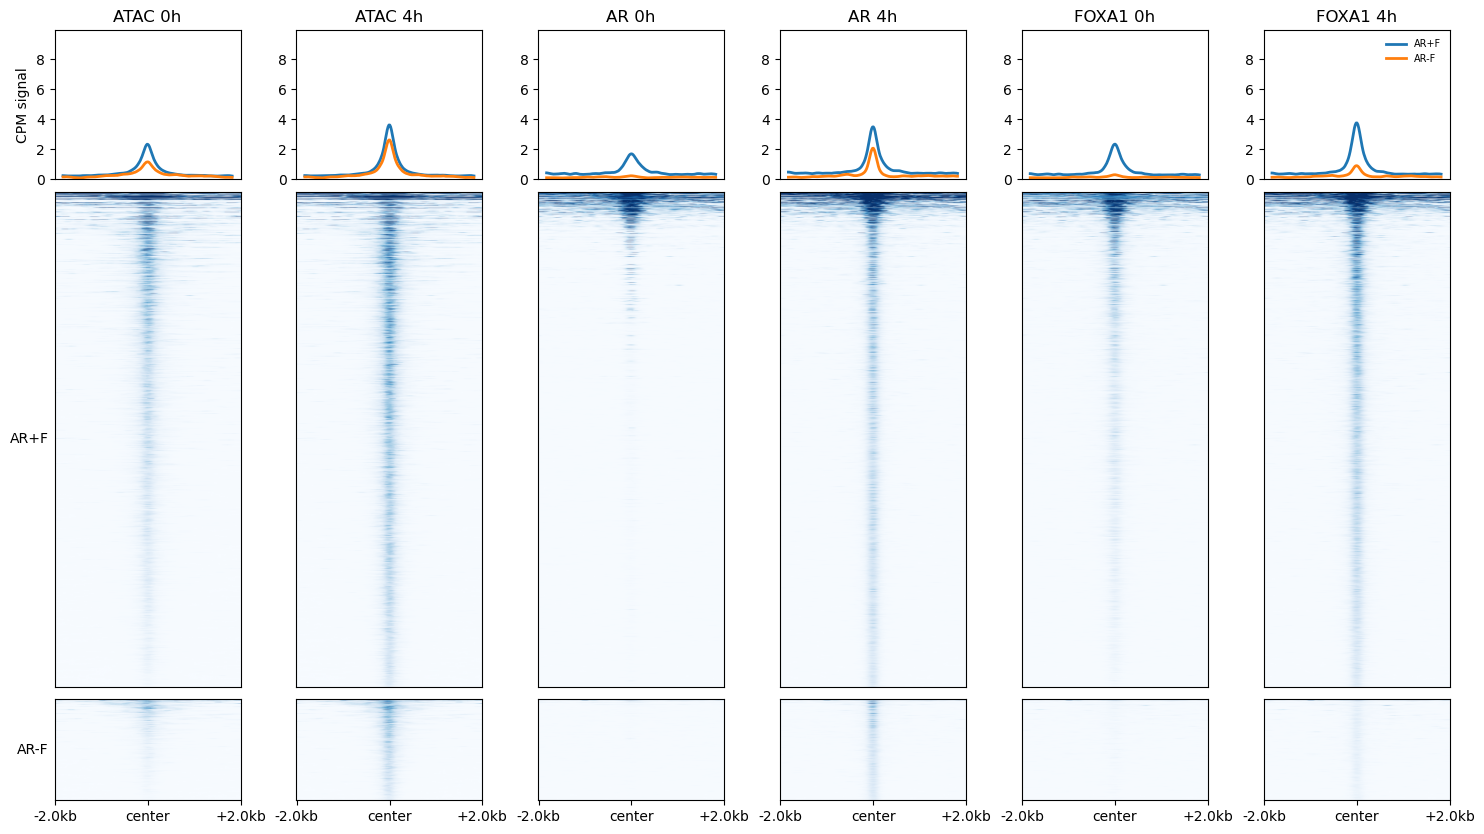

In [8]:
regions = ARpF + ARmF
groups  = {"AR+F": ARpF, "AR-F": ARmF}

bw_order = ["ATAC_0h_r1", "ATAC_0h_r2", "ATAC_4h_r1", "ATAC_4h_r2",
            "AR_0h", "AR_4h", "FOXA1_0h", "FOXA1_4h"]
bigwigs = [BW[k] for k in bw_order]

with timer("extract signal cube"):
    S = np.nan_to_num(regions.signal(bigwigs, n_bins=200, flank=2000, workers=4))
#S = tmm(np.nan_to_num(S))                       # per-track normalization

# group ATAC replicates by averaging their columns -> 6 conditions
S6 = np.stack([
    S[:, [0, 1], :].mean(1),   # ATAC 0h (rep1+rep2)
    S[:, [2, 3], :].mean(1),   # ATAC 4h (rep1+rep2)
    S[:, 4, :], S[:, 5, :],    # AR 0h, AR 4h
    S[:, 6, :], S[:, 7, :],    # FOXA1 0h, FOXA1 4h
], axis=1)
samples = ["ATAC 0h", "ATAC 4h", "AR 0h", "AR 4h", "FOXA1 0h", "FOXA1 4h"]
vmax = float(np.percentile(S6, 99))

with timer("draw heatmap"):
    fig = plot_heatmap(regions, S6, groups=groups, sets=["AR+F", "AR-F"],
                       samples=samples, vmax=vmax, ymax=vmax, height=2000)

## 7. Genomic annotation of AR+F vs AR−F

▶ load genes (GTF) ...
✓ load genes (GTF) — 8.1s
▶ annotate AR+F / AR-F ...
✓ annotate AR+F / AR-F — 0.7s


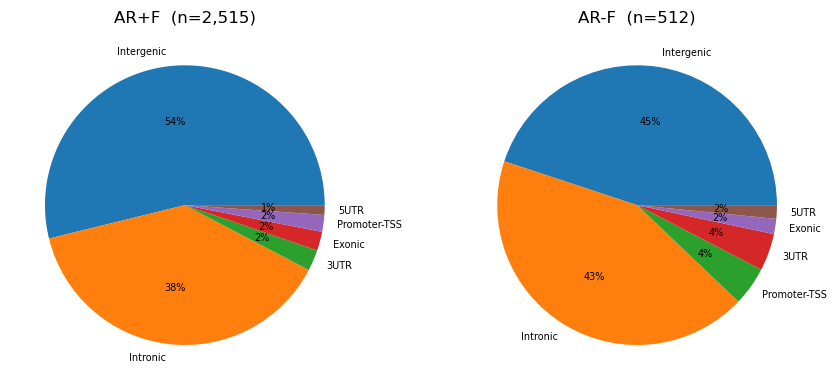

In [9]:
with timer("load genes (GTF)"):
    genes = Genes.make(GTF)

with timer("annotate AR+F / AR-F"):
    annot_pf = genes.annotations(ARpF)
    annot_mf = genes.annotations(ARmF)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, df, title in [(axes[0], annot_pf, "AR+F"), (axes[1], annot_mf, "AR-F")]:
    vc = df["annotation"].value_counts()
    ax.pie(vc.values, labels=vc.index, autopct="%1.0f%%", textprops={"fontsize": 7})
    ax.set_title(f"{title}  (n={len(df):,})")
plt.tight_layout()

## 8. Motif enrichment — AR+F vs AR−F

Scan JASPAR motifs over AR+F, AR−F, and the accessible (ATAC) regions as the
background pool, then bootstrap the log-fold-change. Sorting by `LFC`
(= LFC_AR+F − LFC_AR−F) gives motifs preferential to each set. The scanners
read the windows from the FASTA through its index; to hold the genome in
memory instead, pass `gb.read_fasta(GENOME_FA)` in place of the path.

In [10]:
with timer("index genome FASTA"):
    genome = gb.Genome.from_fasta(GENOME_FA)     # builds hg38.fa.fai once; names and sizes

# background pool: every accessible region (the bootstrap draws 500 at a time)
pool = accessible

with timer("scan motifs (AR+F, AR-F, pool)"):
    mat_pf   = scan_motifs_matrix(ARpF, GENOME_FA, MOTIF_DB, r=250, workers=8)
    mat_mf   = scan_motifs_matrix(ARmF, GENOME_FA, MOTIF_DB, r=250, workers=8)
    mat_pool = scan_motifs_matrix(pool, GENOME_FA, MOTIF_DB, r=250, workers=8)

with timer("bootstrap enrichment"):
    enr = bootstrap_enrichment({"AR+F": mat_pf, "AR-F": mat_mf},
                               ref=mat_pool, boot=100, sample=500, seed=0)

show = ["Factor", "LFC", "LFC_AR+F", "LFC_AR-F"]
ranked = enr.sort_values("LFC", ascending=False)
print("Top motifs in AR+F (FOXA1-dependent):")
display(ranked.head(10)[show])
print("Top motifs in AR-F (FOXA1-independent):")
display(ranked.tail(10)[show].iloc[::-1])

▶ index genome FASTA ...
✓ index genome FASTA — 0.0s
▶ scan motifs (AR+F, AR-F, pool) ...


[motifs]: 100%|██████████| 33/33 [00:00<00:00, 141.42it/s]


[motifs] 4 of 72470 windows run off a chromosome or are missing from the FASTA; their rows count 0.


[motifs]: 100%|██████████| 33/33 [00:18<00:00,  1.76it/s]


✓ scan motifs (AR+F, AR-F, pool) — 31.8s
▶ bootstrap enrichment ...


100%|██████████| 100/100 [00:00<00:00, 266.85it/s]


✓ bootstrap enrichment — 2.6s
Top motifs in AR+F (FOXA1-dependent):


,Factor,LFC,LFC_AR+F,LFC_AR-F
1439,ZN671.H14CORE.0.P.C,0.210842,0.201273,-0.009569
1098,TSH2.H14CORE.0.SG.A,0.153191,0.149330,-0.003861
240,FOXA2.H14CORE.0.PSM.A,0.126346,0.075877,-0.050469
242,FOXA3.H14CORE.0.PS.A,0.108437,0.078202,-0.030235
265,FOXL2.H14CORE.0.PSM.A,0.096419,0.069623,-0.026797
266,FOXM1.H14CORE.0.P.B,0.091988,0.074143,-0.017846
271,FOXP1.H14CORE.0.PS.A,0.091605,0.075136,-0.016469
262,FOXK1.H14CORE.0.PS.A,0.089239,0.056245,-0.032994
238,FOXA1.H14CORE.0.P.B,0.082882,0.052795,-0.030086
1513,ZN800.H14CORE.0.PSG.A,0.075093,0.038774,-0.036320


Top motifs in AR-F (FOXA1-independent):


,Factor,LFC,LFC_AR+F,LFC_AR-F
7,ANDR.H14CORE.0.P.B,-0.152667,0.078639,0.231306
836,PRGR.H14CORE.0.P.B,-0.091029,0.067898,0.158927
293,GCR.H14CORE.0.PS.A,-0.085528,0.034008,0.119535
491,KLF16.H14CORE.1.P.B,-0.079514,-0.240093,-0.160579
1559,ZNF48.H14CORE.0.PSG.A,-0.071219,-0.041029,0.030190
553,MAZ.H14CORE.1.P.B,-0.070974,-0.177320,-0.106346
1122,VEZF1.H14CORE.1.P.B,-0.063601,-0.122012,-0.058411
557,MCR.H14CORE.0.S.B,-0.057377,0.027718,0.085095
1121,VEZF1.H14CORE.0.P.C,-0.056297,-0.148801,-0.092504
506,KMT2A.H14CORE.0.P.B,-0.053831,-0.302884,-0.249053


## 9. ChIP-Atlas (atlas) differential enrichment

Build a 1 kb bin × track index over the ChIP-Atlas hg38 collection, then use
each region set as the other's reference to find TF tracks differentially
enriched between AR+F and AR−F.

> Building the index over the full ChIP-Atlas is heavy (minutes, several GB
> RAM). `atlas.save("chipatlas_hg38_1kb.npz")` / `Atlas.load(...)` reuse it
> across sessions.

In [11]:
with timer("build ChIP-Atlas index (1kb)"):
    atlas = Atlas.make(
        GIGGLE_DIR, chromsizes=CHROMSIZES,
        meta=GIGGLE_META,
        name_pattern=r"([^.]+)",                       # SRX23002840.20.bed.gz -> SRX23002840
        meta_columns=["id", "antigen", "class", "cell_line"],  # meta TSV is header-less
        meta_id_col="id",
    )

with timer("atlas search AR+F vs AR-F"):
    enr_pf = atlas.search(ARpF, ref=ARmF)    # enriched in AR+F over AR-F
    enr_mf = atlas.search(ARmF, ref=ARpF)    # enriched in AR-F over AR+F

cols = ["name", "antigen", "class", "cell_line", "overlaps", "log2_odds", "giggle_score"]
print("TF tracks enriched in AR+F (FOXA1-dependent):")
display(enr_pf.head(15)[cols])
print("TF tracks enriched in AR-F (FOXA1-independent):")
display(enr_mf.head(15)[cols])

▶ build ChIP-Atlas index (1kb) ...


[atlas index]: 100%|██████████| 33368/33368 [00:18<00:00, 1850.83it/s]


✓ build ChIP-Atlas index (1kb) — 42.5s
▶ atlas search AR+F vs AR-F ...
✓ atlas search AR+F vs AR-F — 5.0s
TF tracks enriched in AR+F (FOXA1-dependent):


,name,antigen,class,cell_line,overlaps,log2_odds,giggle_score
0,SRX23002840,FOXA1,Prostate,LNCAP,1329,7.519583,964.923631
1,SRX23002841,FOXA1,Prostate,LNCAP,1089,7.056433,700.212091
2,SRX18285237,FOXA1,Prostate,LNCAP,1847,4.287255,618.551089
3,SRX14353424,FOXA1,Prostate,LNCAP,1990,4.058525,604.652460
4,SRX18285235,FOXA1,Prostate,LNCAP,1722,4.333244,580.711304
5,SRX062360,FOXA1,Prostate,LNCAP,1564,4.546911,564.964852
6,SRX14353423,FOXA1,Prostate,LNCAP,1756,4.155838,548.736062
7,SRX5577144,Epitope tags,Prostate,LNCAP,1779,4.090175,540.034633
8,SRX1885188,FOXA1,Prostate,LNCAP,2044,3.775184,533.691700
9,SRX18285236,FOXA1,Prostate,LNCAP,1470,4.498439,515.002750


TF tracks enriched in AR-F (FOXA1-independent):


,name,antigen,class,cell_line,overlaps,log2_odds,giggle_score
0,SRX3070471,NR3C1,Breast,MCF 10A,151,1.985641,57.274594
1,SRX3070475,NR3C1,Breast,MCF 10A,120,2.021899,49.016228
2,SRX21439743,ESR1,Prostate,LNCAP,452,1.518987,46.612336
3,SRX3070473,NR3C1,Breast,MCF 10A,120,1.969408,45.866518
4,SRX306516,AR,Prostate,DU 145,161,1.690385,39.808143
5,SRX19970679,AR,Prostate,PC-346C,167,1.537133,31.894465
6,SRX8520802,NR3C1,Breast,HCC1187,173,1.506006,31.057426
7,SRX21439744,ESR1,Prostate,LNCAP,336,1.292770,30.240255
8,SRX3070469,NR3C1,Breast,MCF 10A,53,2.255766,30.173945
9,SRX21439742,ESR1,Prostate,LNCAP,295,1.284194,28.358706


## 10. Browser view — `chr19:50,792,009-50,923,669`

All six conditions as signal tracks (ATAC replicates passed as a **list** of
bigwigs are averaged into one track), their peak calls, and gene models. The
region string is 0-based, half-open like every table.

▶ browser render ...
✓ browser render — 1.0s


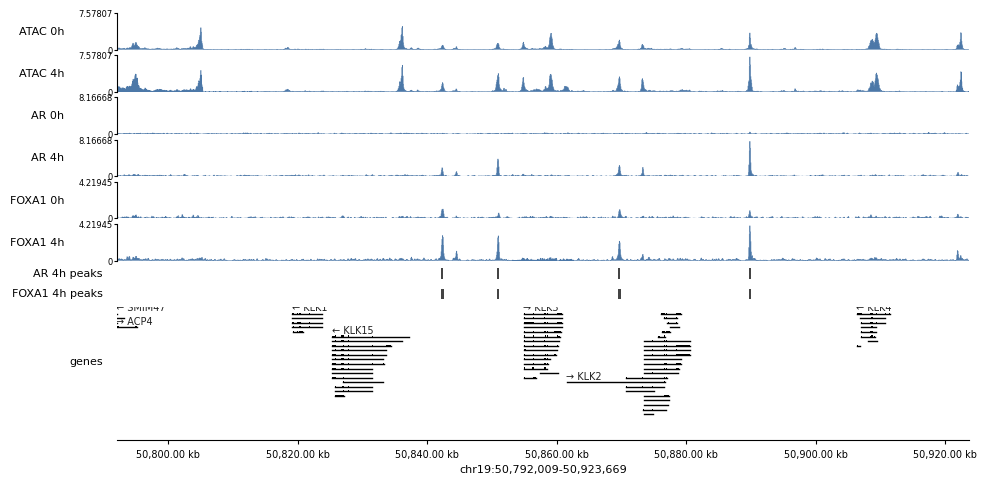

In [12]:
region = "chr19:50,792,009-50,923,669"
tracks = {
    "ATAC 0h":   [BW["ATAC_0h_r1"], BW["ATAC_0h_r2"]],   # list -> averaged
    "ATAC 4h":   [BW["ATAC_4h_r1"], BW["ATAC_4h_r2"]],
    "AR 0h":     BW["AR_0h"],
    "AR 4h":     BW["AR_4h"],
    "FOXA1 0h":  BW["FOXA1_0h"],
    "FOXA1 4h":  BW["FOXA1_4h"],
    "AR 4h peaks":    PEAK["AR_4h"],
    "FOXA1 4h peaks": PEAK["FOXA1_4h"],
    "genes":     genes,
}
# share the y-axis within each assay so the 0h -> 4h gain is honest
with timer("browser render"):
    fig, axes = browser(region, tracks, bw_n_bins=2000, figsize=(11, None),
                        bw_share=[["ATAC 0h", "ATAC 4h"],
                                  ["AR 0h", "AR 4h"],
                                  ["FOXA1 0h", "FOXA1 4h"]])